## 违约预测（LR + RF + XGBoost + LightGBM）


### 1. 数据概览与样本分割

In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore")
import xgboost as xgb
import lightgbm as lgb
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    precision_recall_curve, average_precision_score
)
from sklearn.metrics import roc_curve as _roc_curve
from sklearn.metrics import roc_auc_score as _roc_auc_score

plt.rcParams['font.sans-serif'] = ['SimHei']

In [ ]:
# 读取清洗后数据（由 data_prepare.ipynb 导出）
DATA_DIR = Path("../data")
df = pd.read_csv(DATA_DIR / "myself_loan_clean.csv", low_memory=False)

df.describe()

,loan_amnt,funded_amnt,funded_amnt_inv,int_rate,installment,dti,annual_inc,delinq_2yrs,mths_since_last_delinq,pub_rec,...,bc_util,all_util,tot_cur_bal,total_rev_hi_lim,acc_now_delinq,num_accts_ever_120_pd,num_tl_90g_dpd_24m,pub_rec_bankruptcies,is_default,term_months
count,167981.000000,167981.000000,167981.000000,167981.000000,167981.000000,167981.000000,1.679810e+05,167981.000000,167981.000000,167981.000000,...,167981.000000,167981.000000,1.679810e+05,1.679810e+05,167981.0,167981.000000,167981.000000,167981.000000,167981.000000,167981.000000
mean,16321.180818,16321.180818,16318.340089,12.856414,471.941622,19.395814,8.443008e+04,0.228931,117.140909,0.116632,...,50.501763,54.990457,1.526429e+05,3.999457e+04,0.0,0.464154,0.059102,0.116531,0.011757,43.744019
std,10149.420673,10149.420673,10150.347914,5.167734,284.885983,13.768773,9.138947e+04,0.750204,72.478768,0.326608,...,28.653276,20.286237,1.725383e+05,3.660799e+04,0.0,1.385645,0.434940,0.326417,0.107792,11.219954
min,1000.000000,1000.000000,725.000000,6.000000,30.480000,0.000000,2.500000e+01,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000e+00,2.000000e+02,0.0,0.000000,0.000000,0.000000,0.000000,36.000000
25%,9000.000000,9000.000000,9000.000000,8.460000,261.270000,11.930000,5.000000e+04,0.000000,39.000000,0.000000,...,27.100000,41.000000,3.030800e+04,1.770000e+04,0.0,0.000000,0.000000,0.000000,0.000000,36.000000
50%,14500.000000,14500.000000,14500.000000,11.800000,395.160000,18.000000,7.000000e+04,0.000000,180.000000,0.000000,...,49.400000,56.000000,8.387100e+04,3.060000e+04,0.0,0.000000,0.000000,0.000000,0.000000,36.000000
75%,22400.000000,22400.000000,22400.000000,16.140000,634.080000,25.090000,1.000000e+05,0.000000,180.000000,0.000000,...,74.600000,69.000000,2.312480e+05,5.070000e+04,0.0,0.000000,0.000000,0.000000,0.000000,60.000000
max,40000.000000,40000.000000,40000.000000,30.990000,1618.240000,999.000000,9.757200e+06,58.000000,180.000000,6.000000,...,183.800000,188.000000,9.971659e+06,1.514001e+06,0.0,58.000000,58.000000,6.000000,1.000000,60.000000


In [7]:
ml_df = df.copy()
#定义数值特征和分类特征
num_cols = [
    "int_rate", "dti", "loan_amnt", "funded_amnt", "installment",
    "delinq_2yrs", "mths_since_last_delinq", "revol_util", "open_acc", "total_acc",
    "inq_last_6mths", "annual_inc", "term_months", "revol_bal"
]
cat_cols = ["grade", "purpose", "home_ownership"]


In [ ]:
X_num=ml_df[num_cols]
X_cat=pd.get_dummies(ml_df[cat_cols],drop_first=True,dtype=float) #drop_first=True是对每个分类删除第一个分类特征，可以避免多重共线性，dtype=float是转换为浮点数
display(X_num)
display(X_cat)

,int_rate,dti,loan_amnt,funded_amnt,installment,delinq_2yrs,mths_since_last_delinq,revol_util,open_acc,total_acc,inq_last_6mths,annual_inc,term_months,revol_bal
0,13.56,18.24,2500,2500,84.92,0,180.0,10.3,9,34,1,55000.0,36,4341
1,18.94,26.52,30000,30000,777.23,0,71.0,24.2,13,44,0,90000.0,60,12315
2,17.97,10.51,5000,5000,180.69,0,180.0,19.1,8,13,0,59280.0,36,4599
3,18.94,16.74,4000,4000,146.51,0,180.0,78.1,10,13,0,92000.0,36,5468
4,16.14,26.35,30000,30000,731.78,0,180.0,3.6,12,26,0,57250.0,60,829
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
167976,11.55,18.58,20000,20000,660.00,0,180.0,37.0,6,9,0,62400.0,36,11208
167977,13.56,17.34,14000,14000,475.51,1,12.0,33.8,10,17,0,60000.0,36,12952
167978,13.56,21.26,25000,25000,849.11,0,180.0,58.8,10,14,0,280000.0,36,64057
167979,10.47,27.13,10500,10500,341.13,0,180.0,1.4,11,15,0,35000.0,36,238


,grade_B,grade_C,grade_D,grade_E,grade_F,grade_G,purpose_credit_card,purpose_debt_consolidation,purpose_home_improvement,purpose_house,purpose_major_purchase,purpose_medical,purpose_moving,purpose_other,purpose_renewable_energy,purpose_small_business,purpose_vacation,home_ownership_MORTGAGE,home_ownership_OWN,home_ownership_RENT
0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
167976,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
167977,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
167978,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
167979,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [19]:
X=pd.concat([X_num,X_cat],axis=1)
display(X)
y=ml_df['is_default'].values
y

,int_rate,dti,loan_amnt,funded_amnt,installment,delinq_2yrs,mths_since_last_delinq,revol_util,open_acc,total_acc,...,purpose_major_purchase,purpose_medical,purpose_moving,purpose_other,purpose_renewable_energy,purpose_small_business,purpose_vacation,home_ownership_MORTGAGE,home_ownership_OWN,home_ownership_RENT
0,13.56,18.24,2500,2500,84.92,0,180.0,10.3,9,34,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,18.94,26.52,30000,30000,777.23,0,71.0,24.2,13,44,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,17.97,10.51,5000,5000,180.69,0,180.0,19.1,8,13,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,18.94,16.74,4000,4000,146.51,0,180.0,78.1,10,13,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,16.14,26.35,30000,30000,731.78,0,180.0,3.6,12,26,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
167976,11.55,18.58,20000,20000,660.00,0,180.0,37.0,6,9,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
167977,13.56,17.34,14000,14000,475.51,1,12.0,33.8,10,17,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
167978,13.56,21.26,25000,25000,849.11,0,180.0,58.8,10,14,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
167979,10.47,27.13,10500,10500,341.13,0,180.0,1.4,11,15,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


array([0, 0, 0, ..., 0, 0, 0], shape=(167981,))

In [26]:
#划分训练集和测试集
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y) #stratify=y是按y的所有类别（是否违约）划分，使训练集和测试集的违约率相同

#标准化
scaler=StandardScaler()
X_train_s=scaler.fit_transform(X_train) #标准化训练集
X_test_s=scaler.transform(X_test) #用训练集的结果标准化测试集

print('特征个数:',X_train.shape[1],'| 训练集样本数:',X_train.shape[0],'| 测试集样本数:',X_test.shape[0],'| 平均违约率:',y.mean().round(4))

特征个数: 34 | 训练集样本数: 134384 | 测试集样本数: 33597 | 平均违约率: 0.0118


**数据与样本解读：**

- **特征维度 34**：由数值特征（利率、DTI、金额、还款、逾期、收入等）与分类特征（grade、purpose、home_ownership 的 One-Hot）组成，覆盖了信用定价、还款能力、历史行为等风控常用维度。
- **训练 134384 / 测试 33597**：按 8:2 划分且 `stratify=y`，保证训练/测试集中违约比例一致，评估更可靠。
- **违约率约 1.18%**：典型**高度不平衡**场景。**不能只看准确率，需关注精确率/召回率/F1 和 AUC**，必要时用 `class_weight='balanced'` 或过采样/欠采样。

### 2. 训练模型

- **Logistic Regression**：可解释性好，适合风控汇报
- **Random Forest**：非线性、特征重要性直观
- **XGBoost / LightGBM**：梯度提升树，表格数据常用，不平衡时用 `scale_pos_weight`

In [54]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

#Logistic Regression
lr = LogisticRegression(max_iter=1000,random_state=42,class_weight='balanced')#class_weight="balanced"是用于处理不平衡数据集的参数，它会使模型在训练时对少数类样本给予更多的关注(预测错一个违约样本，损失会大幅增加)，从而避免少数类样本被错误分类。
lr.fit(X_train_s,y_train)
y_pred_lr=lr.predict(X_test_s) #预测违约/不违约，分界线为0.5,0是违约，1是不违约
y_proba_lr=lr.predict_proba(X_test_s) #输出不违约概率和违约概率，相加为1，后面再取第二列即违约概率
y_proba_lr=y_proba_lr[:,1]


In [55]:
#Random Forest
rf=RandomForestClassifier(n_estimators=100,max_depth=10,random_state=42,class_weight='balanced')
rf.fit(X_train,y_train)
y_pred_rf=rf.predict(X_test)
y_proba_rf=rf.predict_proba(X_test)[:,1]


In [57]:
#XGBoost / 不平衡用 scale_pos_weight）
scale_pos=sum(y_train==0)/sum(y_train==1)
xgb_clf=xgb.XGBClassifier(n_estimators=100,max_depth=6,random_state=42,eval_metric='logloss',scale_pos_weight=scale_pos)
xgb_clf.fit(X_train,y_train)
y_pred_xgb=xgb_clf.predict(X_test)
y_proba_xgb=xgb_clf.predict_proba(X_test)[:,1]

In [59]:
#LightGBM
lgb_clf=lgb.LGBMClassifier(n_estimators=100,max_depth=6,random_state=42,verbose=-1,scale_pos_weight=scale_pos)
lgb_clf.fit(X_train,y_train)
y_pred_lgb=lgb_clf.predict(X_test)
y_proba_lgb=lgb_clf.predict_proba(X_test)[:,1]

### 3. 评估指标：准确率、精确率、召回率、AUC-ROC、KS

下面用到的**混淆矩阵**约定（二分类，Positive=违约=1， Negative=不违约=0）：
- **TP**（True Positive）：真实违约，预测违约
- **TN**（True Negative）：真实不违约，预测不违约
- **FP**（False Positive）：真实不违约，预测违约（误报）
- **FN**（False Negative）：真实违约，预测不违约（漏报）

---

#### 1）准确率（Accuracy）

**公式**：  
$$ \text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN} = \frac{\text{预测对的样本数}}{\text{总样本数}} $$

**含义**：所有样本中预测正确的比例。  
**注意**：在违约率极低时（如 1%），模型“全预测不违约”准确率也有约 99%，因此**不能单独用准确率衡量**，需结合精确率、召回率、AUC、KS。

---

#### 2）精确率（Precision）

**公式**：  
$$ \text{Precision} = \frac{TP}{TP + FP} = \frac{\text{预测为违约且真的违约}}{\text{预测为违约的总数}} $$

**含义**：在**预测为违约**的样本里，真正违约的比例；越高说明误报越少。业务上可理解为“拦截的客户里有多少真是坏人”。

---

#### 3）召回率（Recall）

**公式**：  
$$ \text{Recall} = \frac{TP}{TP + FN} = \frac{\text{预测为违约且真的违约}}{\text{真实违约的总数}} $$

**含义**：在**真实违约**的样本里，被模型找出来的比例；越高说明漏掉的违约越少。业务上可理解为“真的坏人里我们抓住了多少”。

---

#### 4）AUC-ROC

- **ROC 曲线**：横轴为 **FPR**（False Positive Rate = FP/(FP+TN)，即“好人被误判成违约的比例”），纵轴为 **TPR**（True Positive Rate = TP/(TP+FN)，即召回率）。对每个分类阈值得到一点 (FPR, TPR)，连成曲线。
- **AUC**（Area Under Curve）：ROC 曲线下的面积，取值 [0, 1]。  
  - AUC = 0.5：和随机猜无异；AUC 越接近 1，说明模型**排序能力**越好（正样本得分整体高于负样本）。
- **公式**：  
  $$ \text{AUC} = P(\text{随机选一个正样本的得分} > \text{随机选一个负样本的得分}) $$  
  即：随机取一违约、一不违约，模型给违约的预测概率高于不违约的概率的几率。

---

#### 5）KS（Kolmogorov-Smirnov）

**公式**：  
$$ \text{KS} = \max_{\text{阈值 } t} \big| \text{TPR}(t) - \text{FPR}(t) \big| $$

**含义**：在所有阈值下，**TPR 与 FPR 之差**的最大值。KS 越大，说明存在某个阈值能把“违约”与“不违约”的分布区分得越开，**区分度**越好。风控中常用 KS > 0.3 作为模型可用的参考。

---

下面用以上指标评估各模型；ROC 曲线见本节后图。

In [60]:
def ks_score(y_true,y_proba):
    fpr,tpr,_=_roc_curve(y_true,y_proba) #roc_curve依次返回fpr,tpr,thresholds
    return np.max(np.abs(tpr-fpr)) #返回tpr-fpr的最大值，即ks值

In [61]:
def print_metrics(name, y_true, y_pred, y_proba=None):
    print(f"--- {name} ---")
    print("Accuracy:", round(accuracy_score(y_true, y_pred), 4))
    print("Precision:", round(precision_score(y_true, y_pred, zero_division=0), 4))
    print("Recall:", round(recall_score(y_true, y_pred, zero_division=0), 4))
    print("F1:", round(f1_score(y_true, y_pred, zero_division=0), 4)) #F1是精确率和召回率的调和平均数，用于衡量模型的综合性能，越接近1，说明模型的综合性能越好
   
    print("ROC-AUC:", round(roc_auc_score(y_true, y_proba), 4))
    print("KS:", round(ks_score(y_true, y_proba), 4))
    print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))
    print()

print_metrics("Logistic Regression", y_test, y_pred_lr, y_proba_lr)
print_metrics("Random Forest", y_test, y_pred_rf, y_proba_rf)
print_metrics("XGBoost", y_test, y_pred_xgb, y_proba_xgb)
print_metrics("LightGBM", y_test, y_pred_lgb, y_proba_lgb)


# 汇总：准确率、精确率、召回率、AUC-ROC、KS（含 XGB/LGB 若已训练）
models = [("Logistic Regression", y_pred_lr, y_proba_lr), ("Random Forest", y_pred_rf, y_proba_rf)]
models.append(("XGBoost", y_pred_xgb, y_proba_xgb))
models.append(("LightGBM", y_pred_lgb, y_proba_lgb))
eval_summary = pd.DataFrame({
    "模型": [m[0] for m in models],
    "准确率": [round(accuracy_score(y_test, m[1]), 4) for m in models],
    "精确率": [round(precision_score(y_test, m[1], zero_division=0), 4) for m in models],
    "召回率": [round(recall_score(y_test, m[1], zero_division=0), 4) for m in models],
    "AUC-ROC": [round(roc_auc_score(y_test, m[2]), 4) for m in models],
    "KS": [round(ks_score(y_test, m[2]), 4) for m in models],
})
eval_summary

--- Logistic Regression ---
Accuracy: 0.6468
Precision: 0.0223
Recall: 0.6785
F1: 0.0432
ROC-AUC: 0.7164
KS: 0.3253
Confusion Matrix:
 [[21463 11739]
 [  127   268]]

--- Random Forest ---
Accuracy: 0.8252
Precision: 0.0223
Recall: 0.3241
F1: 0.0418
ROC-AUC: 0.6889
KS: 0.3112
Confusion Matrix:
 [[27595  5607]
 [  267   128]]

--- XGBoost ---
Accuracy: 0.8921
Precision: 0.0222
Recall: 0.1899
F1: 0.0397
ROC-AUC: 0.6099
KS: 0.1831
Confusion Matrix:
 [[29898  3304]
 [  320    75]]

--- LightGBM ---
Accuracy: 0.7542
Precision: 0.022
Recall: 0.4582
F1: 0.042
ROC-AUC: 0.6568
KS: 0.2444
Confusion Matrix:
 [[25158  8044]
 [  214   181]]



,模型,准确率,精确率,召回率,AUC-ROC,KS
0,Logistic Regression,0.6468,0.0223,0.6785,0.7164,0.3253
1,Random Forest,0.8252,0.0223,0.3241,0.6889,0.3112
2,XGBoost,0.8921,0.0222,0.1899,0.6099,0.1831
3,LightGBM,0.7542,0.0220,0.4582,0.6568,0.2444


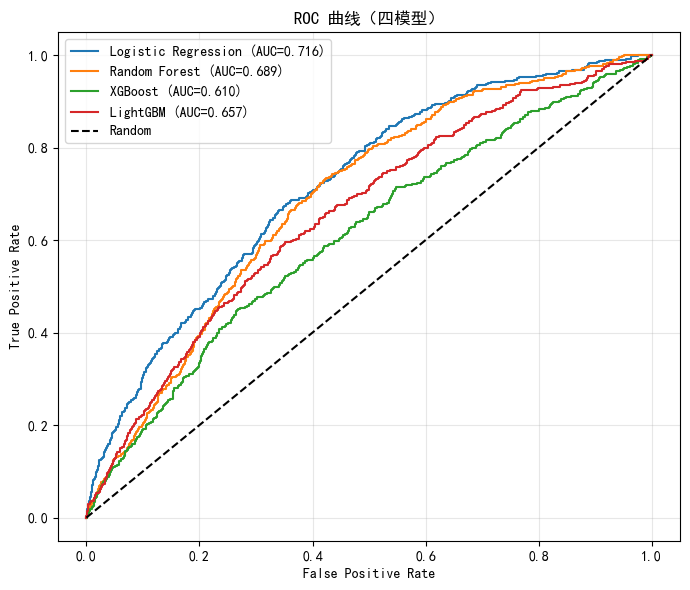

In [69]:
fig, ax = plt.subplots(figsize=(7, 6))

for name, y_proba in [
    ("Logistic Regression", y_proba_lr),
    ("Random Forest", y_proba_rf),
    ("XGBoost", y_proba_xgb),
    ("LightGBM", y_proba_lgb),
]:
    fpr, tpr, _ = _roc_curve(y_test, y_proba)
    auc_val = _roc_auc_score(y_test, y_proba)
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc_val:.3f})")

ax.plot([0, 1], [0, 1], "k--", label="Random")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC 曲线（四模型）")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

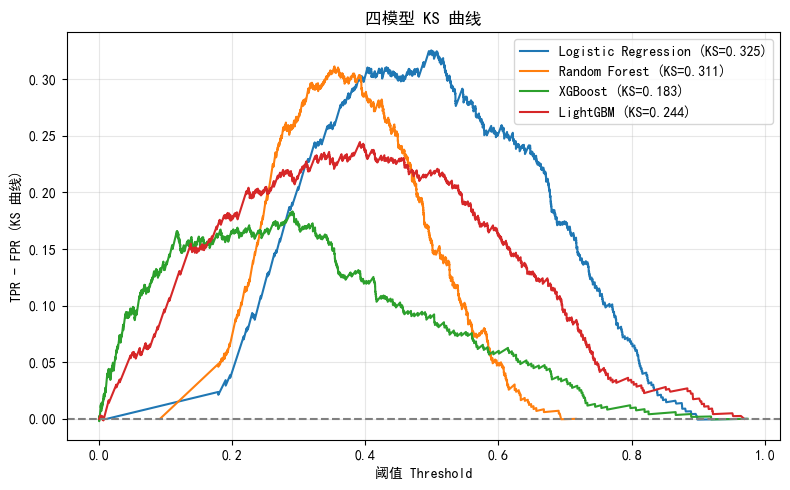

In [71]:
# 四个模型：(名称, 违约概率)
ks_models = [
    ("Logistic Regression", y_proba_lr),
    ("Random Forest", y_proba_rf),
]

ks_models.append(("XGBoost", y_proba_xgb))
ks_models.append(("LightGBM", y_proba_lgb))

fig, ax = plt.subplots(figsize=(8, 5))

for name, y_proba in ks_models:
    fpr, tpr, thresholds = _roc_curve(y_test, y_proba)
    # KS 曲线 = TPR - FPR 随阈值变化
    ks_curve = tpr - fpr
    ks_value = np.max(ks_curve)
    # 横轴用阈值（和 fpr/tpr 等长，前面 roc_curve 会多一个点，取前 len(thresholds) 个）
    thresh_plot = np.append(thresholds, 1)  # 或直接用 np.arange(len(ks_curve))
    ax.plot(thresholds, ks_curve, label=f"{name} (KS={ks_value:.3f})")

ax.set_xlabel("阈值 Threshold")
ax.set_ylabel("TPR - FPR (KS 曲线)")
ax.set_title("四模型 KS 曲线")
ax.legend()
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color="gray", linestyle="--")
plt.tight_layout()
plt.show()

- **准确率**：XGB 最高（约 89.2%），其次 RF（82.5%）、LGB（75.4%）、LR（64.7%）；但因违约率仅 1.18%，把所有人都判为"不违约"准确率也有约 98.8%，故**不能单独用准确率衡量**。
- **精确率**：四模型均约 2.2%～2.23%，即预测为"违约"的样本里真正违约的很少，**误报多**。在风控中可对应"拦截了多少笔、其中多少是误伤"，需结合业务成本与阈值权衡。
- **召回率**：LR 最高（约 67.9%），其次 LGB（45.8%）、RF（32.4%）、XGB（19.0%）；LR 更能**找出真正的违约客户**，XGB 最保守、漏掉更多违约。
- **AUC-ROC**：LR（0.716）> RF（0.689）> LGB（0.657）> XGB（0.610），在**排序能力**上 LR 最好，XGB 在本样本/设定下相对较弱，四条曲线均明显高于随机（0.5），说明模型学到了有效信号。
- **KS**：LR（0.325）、RF（0.311）达常见风控要求 KS>0.3 的区分度；LGB（0.244）、XGB（0.183）略低。若业务更怕"漏掉违约"可优先选 **LR**（召回与 KS 均优），更怕"误拒好人"可提高阈值或选更保守模型。
- **在极度不平衡下，AUC 与 KS 比单一阈值下的准确率/精确率/召回率更稳定，适合做模型对比与阈值选择。**
